# 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Define Paths and Load Labels

In [ ]:
import pandas as pd
import os

# Define the base path to your folder
base_path = '/content/drive/MyDrive/APTOS DATASET/'

# Define paths to CSVs
train_csv_path = os.path.join(base_path, 'train_1.csv')
valid_csv_path = os.path.join(base_path, 'valid.csv')

# Load the CSV files
train_df = pd.read_csv(train_csv_path)
valid_df = pd.read_csv(valid_csv_path)

# Ensure 'diagnosis' is a string for categorical classification
train_df['diagnosis'] = train_df['diagnosis'].astype(str)
valid_df['diagnosis'] = valid_df['diagnosis'].astype(str)

# Add '.png' to id_code if it's missing
train_df['id_code'] = train_df['id_code'].apply(lambda x: x if x.endswith('.png') else f"{x}.png")
valid_df['id_code'] = valid_df['id_code'].apply(lambda x: x if x.endswith('.png') else f"{x}.png")

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(valid_df)}")

Training samples: 2930
Validation samples: 366


# 3. Data Augmentation and Generators

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define Augmentation for Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 2. Define Rescaling for Validation (No augmentation here!)
valid_datagen = ImageDataGenerator(rescale=1./255)

# 3. Create the Training Generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=os.path.join(base_path, 'train_images/'),
    x_col="id_code",
    y_col="diagnosis",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# 4. Create the Validation Generator
valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=os.path.join(base_path, 'val_images/'),
    x_col="id_code",
    y_col="diagnosis",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 2930 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.


# Step 2
##1. Building the Model

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

# 1. Load the pre-trained MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base model (don't train it yet)
base_model.trainable = False

# 3. Build the custom head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

##2. Compiling and Callbacks

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Define the Optimizer
optimizer = optimizers.Adam(learning_rate=0.0001)

# Compile
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Setup a Checkpoint to save the best model during training
checkpoint = ModelCheckpoint(
    'diabetic_retinopathy_mobilenet.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

##3. Training the Model

In [ ]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=valid_generator,
    callbacks=[checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.3831 - loss: 1.7232 
Epoch 1: val_loss improved from inf to 0.90181, saving model to diabetic_retinopathy_mobilenet.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 1542s 17s/step - accuracy: 0.3844 - loss: 1.7195 - val_accuracy: 0.6639 - val_loss: 0.9018
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6632 - loss: 0.9784
Epoch 2: val_loss improved from 0.90181 to 0.80296, saving model to diabetic_retinopathy_mobilenet.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 624s 7s/step - accuracy: 0.6632 - loss: 0.9783 - val_accuracy: 0.7131 - val_loss: 0.8030
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6899 - loss: 0.8662
Epoch 3: val_loss improved from 0.80296 to 0.76857, saving model to diabetic_retinopathy_mobilenet.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 636s 7s/step - accuracy: 0.6899 - loss: 0.8662 - val_accuracy: 0.7131 - val_loss: 0.7686
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6903 - loss: 0.8737
Epoch 4: val_loss improved from 0.76857 to 0.75725, saving model to diabetic_retinopathy_mobilenet.h5


...

92/92 ━━━━━━━━━━━━━━━━━━━━ 630s 7s/step - accuracy: 0.7331 - loss: 0.7292 - val_accuracy: 0.7541 - val_loss: 0.6929
Epoch 10/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7540 - loss: 0.7023
Epoch 10: val_loss improved from 0.69295 to 0.69198, saving model to diabetic_retinopathy_mobilenet.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 629s 7s/step - accuracy: 0.7538 - loss: 0.7026 - val_accuracy: 0.7541 - val_loss: 0.6920
Epoch 11/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7307 - loss: 0.7333
Epoch 11: val_loss did not improve from 0.69198
92/92 ━━━━━━━━━━━━━━━━━━━━ 628s 7s/step - accuracy: 0.7308 - loss: 0.7330 - val_accuracy: 0.7541 - val_loss: 0.7004
Epoch 12/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7606 - loss: 0.6827
Epoch 12: val_loss improved from 0.69198 to 0.67932, saving model to diabetic_retinopathy_mobilenet.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 635s 7s/step - accuracy: 0.7605 - loss: 0.6829 - val_accuracy: 0.7678 - val_loss: 0.6793
Epoch 13/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7445 - loss: 0.6904
Epoch 13: val_loss improved from 0.67932 to 0.67752, saving model to diabetic_retinopathy_mobilenet.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 633s 7s/step - accuracy: 0.7445 - loss: 0.6904 - val_accuracy: 0.7432 - val_loss: 0.6775
Epoch 14/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7453 - loss: 0.6844
Epoch 14: val_loss did not improve from 0.67752
92/92 ━━━━━━━━━━━━━━━━━━━━ 657s 7s/step - accuracy: 0.7454 - loss: 0.6843 - val_accuracy: 0.7596 - val_loss: 0.6836
Epoch 15/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7490 - loss: 0.6760
Epoch 15: val_loss improved from 0.67752 to 0.66489, saving model to diabetic_retinopathy_mobilenet.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 640s 7s/step - accuracy: 0.7491 - loss: 0.6761 - val_accuracy: 0.7623 - val_loss: 0.6649


#Step-3
##1. Plotting Plotting Training History (Accuracy and Loss)

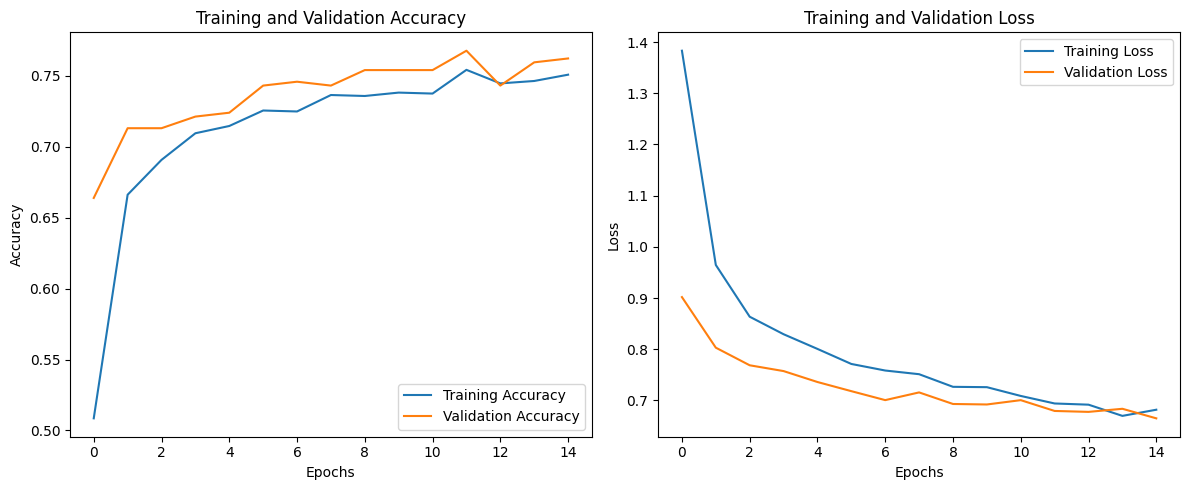

In [ ]:
import matplotlib.pyplot as plt

# Get data from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

##2. Evaluate the Model

In [ ]:
# Evaluate on the validation generator
results = model.evaluate(valid_generator)

print(f"\nValidation Loss: {results[0]:.4f}")
print(f"Validation Accuracy: {results[1]*100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 69s 6s/step - accuracy: 0.7689 - loss: 0.6722

Validation Loss: 0.6649
Validation Accuracy: 76.23%


##3. Download the Model File

In [ ]:
from google.colab import files
files.download('diabetic_retinopathy_mobilenet.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>